# ⚡ Quick Start
## Solving Parameterized PDEs and Learning Operators with **FoLax**

This quick-start guide introduces **FoLax** through a *minimal yet complete*
example, highlighting its unified treatment of **parameterized partial
differential equations (PDEs)**.

The example demonstrates how a **single, physics-based problem definition**
can be reused across two closely related—but conceptually distinct—computational
tasks:

---

### 🧮 Direct Solution of Parameterized PDEs

The governing equations are solved using **classical finite element methods
(FEM)**, where problem parameters—such as spatially varying material properties
or control fields—enter explicitly into the PDE operator.

This mode corresponds to traditional numerical simulation and serves as a
reference for high-fidelity solutions.

---

### 🧠 Physics-Informed Operator Learning

The same physical formulation is used to train a **surrogate operator model**
*without explicitly solving the PDE* or generating labeled solution data.

Instead, learning is driven entirely by the **underlying physical laws** through
a physics-informed, label-free training objective derived from the weighted
residual formulation.

---

By reusing the same mathematical description for both simulation and learning,
FoLax enables a seamless transition from **direct PDE solvers** to
**learned surrogate operators**, while preserving physical consistency and
numerical rigor.

## 1. Problem Setup and Formulation

### 1.1 Parameterized Physics

In many scientific and engineering applications, PDEs depend on spatially varying
or uncertain parameters, such as:
- Heterogeneous material properties
- Coefficient fields
- Boundary or source parameters

In **FoLax**, these quantities are treated as explicit **control parameters** of the PDE.
For example, a heterogeneous coefficient field can be parameterized and supplied
as an input to the element-level residual implementation, thereby defining a
*family of PDEs* rather than a single fixed problem.

### 1.2 FoLax Core Principle

The central idea behind **FoLax** is both simple and powerful:

> **Define the parameterized element-level residual once —  
> FoLax reuses it for FEM assembly, numerical solvers,  
> and physics-informed operator learning.**

The *same residual formulation* is used to:
- Solve the parameterized PDE using FEM, and
- Evaluate a weighted residual–based loss function for physics-informed
  operator learning, mapping from the control/design space to the solution space

This unified formulation eliminates the need to separately generate labeled
solution data by repeatedly solving the PDE for different parameter
realizations.

### 1.3 Problem Overview

We consider **2D small-strain linear elasticity** on a square domain
$\Omega = [0,1] \times [0,1]$, with:

- Prescribed displacements on selected boundaries
- A **spatially heterogeneous material field**, treated as a parameter
- No body forces (for simplicity)

Our objective is to solve this **parameterized elasticity problem** in two complementary ways:
1. **Directly**, by computing the displacement field
   $ u(x) = [u_x(x), u_y(x)]^\top $ using classical finite element methods, and
2. **Indirectly**, by learning a **physics-informed surrogate operator** that maps
   material field to displacement fields without requiring labeled solution data

Both approaches rely on the same underlying variational and residual formulation,
enabling a consistent comparison between direct numerical solutions and
surrogate-based operator learning.

---

### 1.4 Linear elasticity with heterogeneous material

FoLax’s mechanical models are built around the **weighted residual formulation**
of linear elasticity with spatially varying material properties.

#### 1.4.1 Strong form

Find the displacement field $u:\Omega \rightarrow \mathbb{R}^2$ such that

$$
\nabla \cdot \sigma(u,d) + b = 0 \quad \text{in } \Omega,
$$

with boundary conditions

$$
u = \bar{u} \quad \text{on } \Gamma_D,
\qquad
\sigma(u,d)\,n = \bar{t} \quad \text{on } \Gamma_N.
$$

The small-strain tensor is

$$
\varepsilon(u) = \tfrac{1}{2}(\nabla u + \nabla u^\top).
$$

In FoLax, material heterogeneity is typically represented by a **scalar field**
$d(x)$ that scales a reference elasticity tensor $D$:

$$
\sigma(u,d) = d(x)\,D\,\varepsilon(u).
$$

This heterogeneity field is interpolated at quadrature points from nodal values.

---

#### 1.4.2 Weak form (weighted residual)

Let $v$ be a test function vanishing on $\Gamma_D$. The weak form reads

$$
R(u,d;v)
=
\int_\Omega \varepsilon(v) : \sigma(u,d)\, d\Omega
-
\int_\Omega v \cdot b \, d\Omega
-
\int_{\Gamma_N} v \cdot \bar{t}\, d\Gamma
= 0
\quad \forall v.
$$

After finite element discretization on an element $\Omega_e$, this leads to
the **discrete element residual**

$$
r_e(u_e,d) = S_e(d)\,u_e - F_e,
$$

where $u_e$ is the element DOF vector, $S_e$ is the element stiffness matrix,
and $F_e$ is the element force vector.

---

### 1.5 Element-Level Physics Evaluation in FoLax

In **FoLax**, all physical modeling is defined at the **finite element level**.
Each finite element is responsible for providing **three element-level quantities**:

1. **Element loss**, defined as the inner product between the element solution
   vector and the corresponding element residual
2. **Element residual**, representing the weak-form balance of the governing equations
3. **Element stiffness matrix**, obtained from the linearization of the element residual

---

### 1.6 Element Loss and Residual Formulation

FoLax evaluates the element-level residual and stiffness matrix using
**Gauss quadrature**. The scalar element contribution used in the mechanical
loss is defined as

$$
\ell_e(u_e, d) = u_e^\top \, r_e(u_e, d),
$$

where \( u_e \) denotes the element nodal solution vector and
\( r_e \) the corresponding element residual.

At each Gauss point \( x_q \), the element stiffness matrix and force vector
are computed as

$$
S_e(d)
=
\sum_q w_q \, \det(J_q)\, d(x_q)\, B(x_q)^\top D B(x_q),
$$

$$
F_e
=
\sum_q w_q \, \det(J_q)\, N(x_q)^\top b.
$$

---

### 1.7 Element-Level Inputs and Implementation

It is important to note that the following quantities are provided as inputs
to the physics definition at the element level:

- **Element nodal parameters** (e.g. material or control fields)
- **Element nodal solution values**
- **Element nodal coordinates**

These inputs are passed to the `ComputeElement` function, which defines the
physics at the element level.

All element-level physics implementations are located in the
`fol/loss_functions` directory. **This is the only place where the user defines physics in FoLax.**  
Element assembly, boundary condition enforcement, automatic differentiation,
and physics-informed learning workflows are handled automatically by the framework.

In particular, the formulation for
**2D linear elasticity** is implemented in:
fol/loss_functions/mechanical.py

## 2. Implementation and Example

Physics-Informed Fourier Neural Operator (PI-FNO) demo using the FOLAX library
----------------------------------------------------------------------------
Goal:
  Learn an OPERATOR that maps a spatial heterogeneity field K(x,y) to the
  displacement solution U(x,y) = [Ux(x,y), Uy(x,y)] for a 2D linear elasticity
  problem — WITHOUT supervised labels — by minimizing a weighted FE residual loss.

What FOL provides in this example:
  1) A "control" object that generates spatial fields K from low-dim parameters
     (here: Fourier coefficients).
  2) A physics loss object (FE-based) that computes equilibrium
     (includign strongly applied BC).
  3) A training wrapper that connects: coeffs -> K -> FNO -> U -> physics loss.

In [ ]:
# ----------------------------------------------------------------------------
# 2.0) Basic imports + create clean working directory for outputs
# ----------------------------------------------------------------------------
import sys,os
from fol.tools.usefull_functions import *

# Where all artifacts go: checkpoints, plots, exported VTK, logs, etc.
working_directory_name = 'pi_fno_2D_elasticity'
case_dir = os.path.join('.', working_directory_name)
create_clean_directory(working_directory_name)

In [ ]:
# ----------------------------------------------------------------------------
# 2.1) Define the mechanical PDE problem and create FE mesh + FE-based loss
# ----------------------------------------------------------------------------
from fol.loss_functions.mechanical import MechanicalLoss2DQuad

# ===============================================================================
#           2D SQUARE DOMAIN Ω = [0,L] × [0,L]     (L = 1,  N = 30)
# ===============================================================================

#           y
#           ↑
#           │
#           ┌───────────────────────────┐   y = L
#           │                           │
#           │                           │
#           │                           │
#           │           Ω               │   ← square domain
#           │   (structured quad mesh)  │
#           │                           │
#           │                           │
#           │                           │
#           └───────────────────────────┘   y = 0
#           │
#           └──────────────────────────→ x
#           0                          L

# Dirichlet boundary conditions (applied on full vertical edges):
#   LEFT  (x = 0):  Ux = 0.0 ,  Uy = 0.0
#   RIGHT (x = L):  Ux = 0.05,  Uy = 0.05

# Material model:
#   Linear isotropic elasticity
#   Young's modulus E = 1
#   Poisson ratio   ν = 0.3
# ===============================================================================


# Problem settings (domain + Dirichlet BCs)
# L: domain side length
# N: resolution used to represent K(x,y) on a grid (and usually used for mesh)
# Ux_left/right, Uy_left/right: prescribed displacements on left/right boundaries
model_settings = {"L":1,"N":30,
                "Ux_left":0.0,"Ux_right":0.05,
                "Uy_left":0.0,"Uy_right":0.05}

# Create a 2D square FE mesh. Internally, creates nodes/elements
# consistent with a (structured) quad mesh on [0,L]x[0,L].
fe_mesh = create_2D_square_mesh(L=1,N=30)

# Dirichlet boundary conditions dictionary:
#   component -> side -> value
# This tells the mechanical loss what displacement is fixed on boundaries.
bc_dict = {"Ux":{"left":model_settings["Ux_left"],"right":model_settings["Ux_right"]},
            "Uy":{"left":model_settings["Uy_left"],"right":model_settings["Uy_right"]}}

# Linear elastic material parameters
material_dict = {"young_modulus":1,"poisson_ratio":0.3}

# Create an FE-based physics loss:
# MechanicalLoss2DQuad evaluates the 2D elasticity weighted residual using quadrilateral
# elements and numerical integration (Gauss points).
mechanical_loss_2d = MechanicalLoss2DQuad("mechanical_loss_2d",loss_settings={"dirichlet_bc_dict":bc_dict,
                                                                            "num_gp":2,
                                                                            "material_dict":material_dict},
                                                                            fe_mesh=fe_mesh)

# Initialize builds internal FE data structures:
# - connectivity, shape functions, gauss points/weights
# - boundary node sets for Dirichlet BC
# - material matrices, etc.
mechanical_loss_2d.Initialize()

2026-01-28 09:31:15 - Info : mechanical_loss_2d.Initialize - for the proper batching of elements, the batch size is changed from 42 to 29


In [ ]:
# ----------------------------------------------------------------------------
# 2.2) Create an FE solver for reference (ground truth comparison)
# ----------------------------------------------------------------------------

from fol.solvers.fe_linear_residual_based_solver import FiniteElementLinearResidualBasedSolver

# Configure iterative linear solver:
# bicgstab + ILU preconditioner for sparse FE systems
fe_setting = {"linear_solver_settings":{"solver":"JAX-bicgstab","tol":1e-6,"atol":1e-6,
                                            "maxiter":1000,"pre-conditioner":"ilu"}}

# This solver uses the same mechanical_loss_2d configuration (mesh/BC/material)
fe_solver = FiniteElementLinearResidualBasedSolver("lin_fe_solver",mechanical_loss_2d,fe_setting)
fe_solver.Initialize()

2026-01-28 09:34:03 - Info : lin_fe_solver.__init__ - finished in 0.0000 seconds
2026-01-28 09:34:03 - Info : lin_fe_solver.Initialize - finished in 0.0000 seconds


2026-01-28 09:42:32 - Info : fourier_control.Initialize - finished in 0.0107 seconds
2026-01-28 09:42:32 - Info : mechanical_loss_2d.ApplyDirichletBCOnDofVector - finished in 0.0002 seconds
2026-01-28 09:42:32 - Info : mechanical_loss_2d.ComputeJacobianMatrixAndResidualVector - finished in 0.0024 seconds
2026-01-28 09:42:33 - Info : lin_fe_solver.JaxBicgstabLinearSolver - finished in 0.2371 seconds
2026-01-28 09:42:33 - Info : lin_fe_solver.Solve - finished in 0.2401 seconds


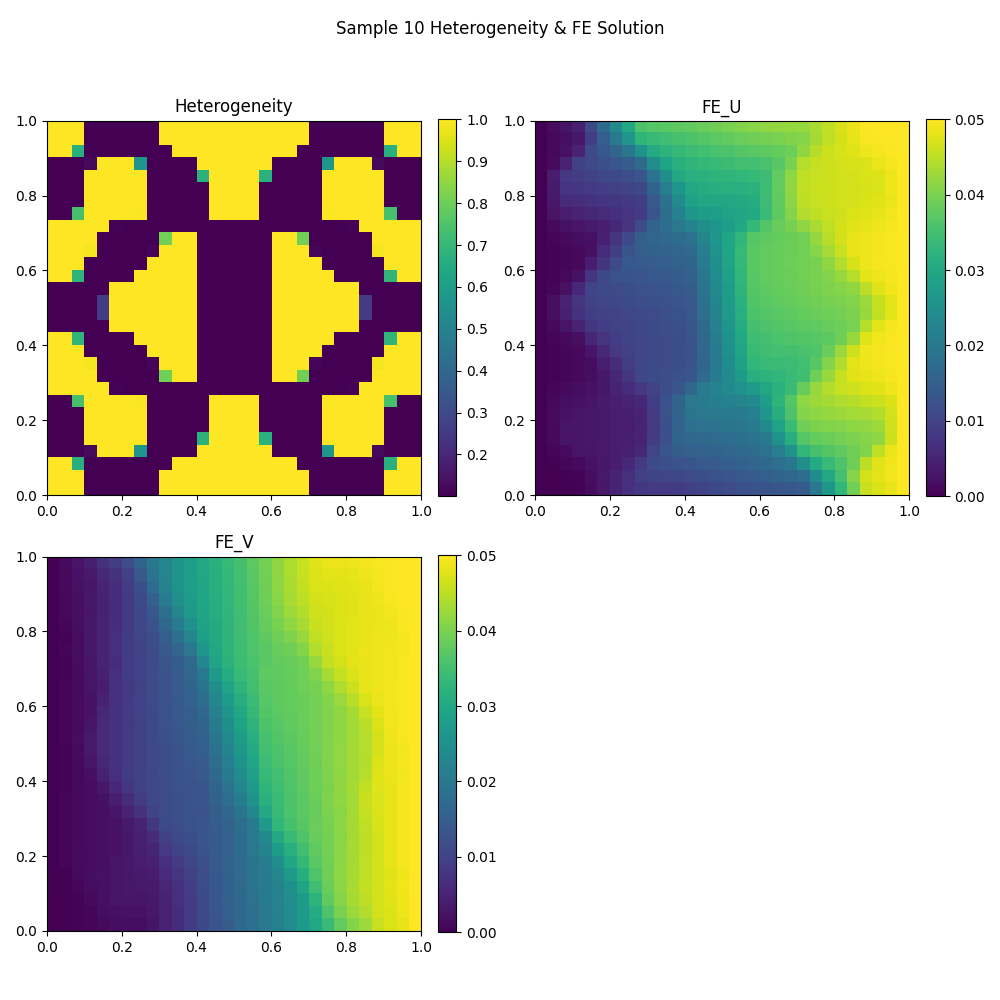

In [ ]:
# ----------------------------------------------------------------------------
# 2.3) Define "control": parameterize the input field K(x,y) using Fourier modes
# ----------------------------------------------------------------------------

from fol.controls.fourier_control import FourierControl
from IPython.display import Image, display

# Create fourier control object tied to the FE mesh (so it can generate K on the mesh/grid)
fourier_control_settings = {"x_freqs":np.array([2,4,6]),"y_freqs":np.array([2,4,6]),"z_freqs":np.array([0]),
                            "beta":20,"min":1e-1,"max":1}
fourier_control = FourierControl("fourier_control",fourier_control_settings,fe_mesh)
fourier_control.Initialize()

# --------------------------------------------------------------------------
# Sample random Fourier coefficients and generate heterogeneous material fields
# --------------------------------------------------------------------------
# coeffs_matrix: (n_samples, n_coeffs)  -> low-dim parameters
# K_matrix:      (n_samples, N*N) or (n_samples, N, N) -> spatial field samples
coeffs_matrix,K_matrix = create_random_fourier_samples(fourier_control,100)

plot_sample_id = 10
# --------------------------------------------------------------------------
# Solve the parameterized PDE using the finite element solver
# --------------------------------------------------------------------------
# Given the sampled heterogeneity field K(x,y), compute the FE displacement
# solution (u_x, u_y) for the selected sample
FE_UV = np.asarray(fe_solver.Solve(K_matrix[plot_sample_id],np.zeros(2*fe_mesh.GetNumberOfNodes()))).flatten()


# --------------------------------------------------------------------------
# Visualize the heterogeneity field and the corresponding FE solution
# --------------------------------------------------------------------------
plot_file_name = os.path.join(case_dir,f'heterogeneity_sample_{plot_sample_id}.png')
plot_mesh_vec_data(model_settings["L"], [K_matrix[plot_sample_id,:],FE_UV[::2],FE_UV[1::2]],
                    subplot_titles= ['Heterogeneity', 'FE_U', 'FE_V'], fig_title = (f'Sample {plot_sample_id} Heterogeneity & FE Solution'),
                    cmap='viridis',block_bool=True, colour_bar=True, colour_bar_name=None,
                    X_axis_name=None, Y_axis_name=None, show=False, file_name=plot_file_name)

display(Image(filename=plot_file_name))

In [ ]:
# ----------------------------------------------------------------------------
# 2.4) Build the FNO (Fourier Neural Operator) in JAX/Flax
# ----------------------------------------------------------------------------

from fol.deep_neural_networks.ported_fourier_neural_operator_networks.fno import FNO
from flax import nnx
import jax

fno_model = FNO(
    in_channels=1,
    out_channels=2,
    hidden_channels=64,
    n_modes=(12,12),
    n_layers=4,
    rngs=nnx.Rngs(0)
)

# Count trainable parameters
params = nnx.state(fno_model, nnx.Param)
total_params  = sum(np.prod(x.shape) for x in jax.tree_util.tree_leaves(params))
print(f"FNO trainable parameters:{total_params}")

# Sanity-check forward pass with a small batch:
# FNO expects shape (batch, Nx, Ny, channels)
# ISince K_matrix is stored as flattened vectors, we reshape to (B,N,N,1)
init_out = fno_model(K_matrix[0:8].reshape(8,model_settings["N"],model_settings["N"],1))

FNO trainable parameters:1427266


In [10]:
# ----------------------------------------------------------------------------
# 2.5) Create Physics-Informed Operator Learning wrapper (PI-FOL)
# ----------------------------------------------------------------------------

import optax
from fol.deep_neural_networks.fourier_parametric_operator_learning import PhysicsInformedFourierParametricOperatorLearning

# Optimizer for the FNO parameters.
num_epochs = 10000
optimizer = optax.chain(optax.adam(1e-6))

# This wrapper is the "glue" that performs operator learning:
# It knows how to:
#   coeffs -> control generates K
#   K -> neural net predicts U
#   U (+ K) -> physics loss computes residual/BC loss
#   optimize NN parameters using optax
pi_fno_pr_learning = PhysicsInformedFourierParametricOperatorLearning(name="pi_fno_pr_learning",
                                                                        control=fourier_control,
                                                                        loss_function=mechanical_loss_2d,
                                                                        flax_neural_network=fno_model,
                                                                        optax_optimizer=optimizer)
# Initialize the trainer
pi_fno_pr_learning.Initialize()

2026-01-28 09:48:24 - Info : pi_fno_pr_learning.Initialize - finished in 0.3075 seconds


2026-01-28 09:49:20 - Info : pi_fno_pr_learning.Train - convergence settings:{'num_epochs': 10000, 'convergence_criterion': 'total_loss', 'relative_error': 1e-100, 'absolute_error': 1e-100}
2026-01-28 09:49:20 - Info : pi_fno_pr_learning.Train - plot settings:{'plot_list': ['total_loss'], 'plot_frequency': 1, 'save_frequency': 100, 'save_directory': './pi_fno_2D_elasticity', 'test_frequency': 1000}
2026-01-28 09:49:20 - Info : pi_fno_pr_learning.Train - restore settings:{'restore': False, 'state_directory': './pi_fno_2D_elasticity/flax_state'}
2026-01-28 09:49:20 - Info : pi_fno_pr_learning.Train - train checkpoint settings:{'least_loss_checkpointing': True, 'least_loss': inf, 'frequency': 1000, 'state_directory': './pi_fno_2D_elasticity/flax_train_state'}
2026-01-28 09:49:20 - Info : pi_fno_pr_learning.Train - test checkpoint settings:{'least_loss_checkpointing': False, 'least_loss': inf, 'frequency': 100, 'state_directory': './pi_fno_2D_elasticity/flax_test_state'}
2026-01-28 09:49:2

  0%|          | 0/10000 [00:00<?, ?it/s]/home/reza/Projects/folax/folax-docs/py-env-gpu/lib/python3.12/site-packages/jax/_src/lax/lax.py:5482: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)
/home/reza/Projects/folax/folax-docs/py-env-gpu/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1280: UserWarning: Some donated buffers were not usable: float32[80,10].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
 10%|█         | 1003/10000 [00:23<03:41, 40.58it/s, train_loss=0.0045113764, test_loss=0.004897836]

2026-01-28 09:49:44 - Info : pi_fno_pr_learning.train_loop - train total_loss improved from inf to 0.004564871080219746
2026-01-28 09:49:44 - Info : pi_fno_pr_learning.SaveCheckPoint - train flax nnx state is saved to ./pi_fno_2D_elasticity/flax_train_state


 20%|██        | 2005/10000 [00:39<03:26, 38.67it/s, train_loss=0.0014652666, test_loss=0.0015302136]

2026-01-28 09:49:59 - Info : pi_fno_pr_learning.train_loop - train total_loss improved from 0.004564871080219746 to 0.0014708224916830659
2026-01-28 09:50:00 - Info : pi_fno_pr_learning.SaveCheckPoint - train flax nnx state is saved to ./pi_fno_2D_elasticity/flax_train_state


...

2026-01-28 09:51:37 - Info : pi_fno_pr_learning.train_loop - train total_loss improved from 0.000950345303863287 to 0.0009336508228443563
2026-01-28 09:51:37 - Info : pi_fno_pr_learning.SaveCheckPoint - train flax nnx state is saved to ./pi_fno_2D_elasticity/flax_train_state


 90%|█████████ | 9008/10000 [02:33<00:22, 44.03it/s, train_loss=0.00092106604, test_loss=0.0009801321]

2026-01-28 09:51:54 - Info : pi_fno_pr_learning.train_loop - train total_loss improved from 0.0009336508228443563 to 0.0009212300064973533
2026-01-28 09:51:54 - Info : pi_fno_pr_learning.SaveCheckPoint - train flax nnx state is saved to ./pi_fno_2D_elasticity/flax_train_state


100%|██████████| 10000/10000 [02:50<00:00, 58.76it/s, train_loss=0.00091147854, test_loss=0.0009713538]

2026-01-28 09:52:10 - Info : pi_fno_pr_learning.train_loop - train total_loss improved from 0.0009212300064973533 to 0.000911478535272181
2026-01-28 09:52:10 - Info : pi_fno_pr_learning.SaveCheckPoint - train flax nnx state is saved to ./pi_fno_2D_elasticity/flax_train_state
2026-01-28 09:52:10 - Info : pi_fno_pr_learning.SaveCheckPoint - final flax nnx state is saved to ./pi_fno_2D_elasticity/flax_final_state
2026-01-28 09:52:10 - Info : pi_fno_pr_learning.Train - finished in 170.4348 seconds


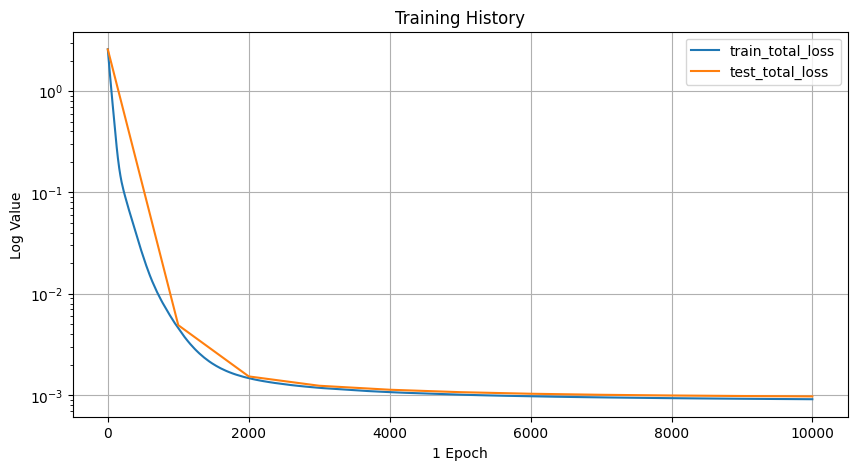

In [11]:
# ----------------------------------------------------------------------------
# 2.6) Train / Test split and training call
# ----------------------------------------------------------------------------
train_start_id, train_end_id = 0, 80
test_start_id, test_end_id = 80, 100

# Train expects tuples for datasets (even if there's only one "input")
# Here: the dataset is only Fourier coefficients; K is generated internally.
#
# In physics-informed settings, "labels" aren't required because loss is physics residual.
pi_fno_pr_learning.Train(train_set=(coeffs_matrix[train_start_id:train_end_id,:],),
                        test_set=(coeffs_matrix[test_start_id:test_end_id,:],),
                        test_frequency=1000, # evaluate on test set every 1000 epochs
                        batch_size=8,
                        # Convergence criteria: extremely strict -> effectively forces full epochs
                        convergence_settings={"num_epochs":num_epochs,"relative_error":1e-100,"absolute_error":1e-100},
                        # Plot/save cadence (writes loss curves)
                        plot_settings={"plot_save_rate":1000},
                        # Checkpointing (keep best loss + periodic saves)
                        train_checkpoint_settings={"least_loss_checkpointing":True,"frequency":1000},
                        working_directory=case_dir)

display(Image(filename=os.path.join(case_dir,f'training_history.png')))

In [12]:
# ----------------------------------------------------------------------------
# 2.7) Load final trained state and run inference for all coefficient samples
# ----------------------------------------------------------------------------
# RestoreState loads weights/optimizer state saved at the end of training.
# "flax_final_state" is the folder created by the trainer.

pi_fno_pr_learning.RestoreState(restore_state_directory=case_dir+"/flax_final_state")
FNO_UVs = pi_fno_pr_learning.Predict(coeffs_matrix)

2026-01-28 09:58:05 - Info : pi_fno_pr_learning.RestoreState - flax nnx state is restored from ./pi_fno_2D_elasticity/flax_final_state
2026-01-28 09:58:09 - Info : pi_fno_pr_learning.Predict - finished in 4.2529 seconds


2026-01-28 09:58:50 - Info : mechanical_loss_2d.ApplyDirichletBCOnDofVector - finished in 0.0002 seconds
2026-01-28 09:58:50 - Info : mechanical_loss_2d.ComputeJacobianMatrixAndResidualVector - finished in 0.0026 seconds
2026-01-28 09:58:50 - Info : lin_fe_solver.JaxBicgstabLinearSolver - finished in 0.2329 seconds
2026-01-28 09:58:50 - Info : lin_fe_solver.Solve - finished in 0.2363 seconds


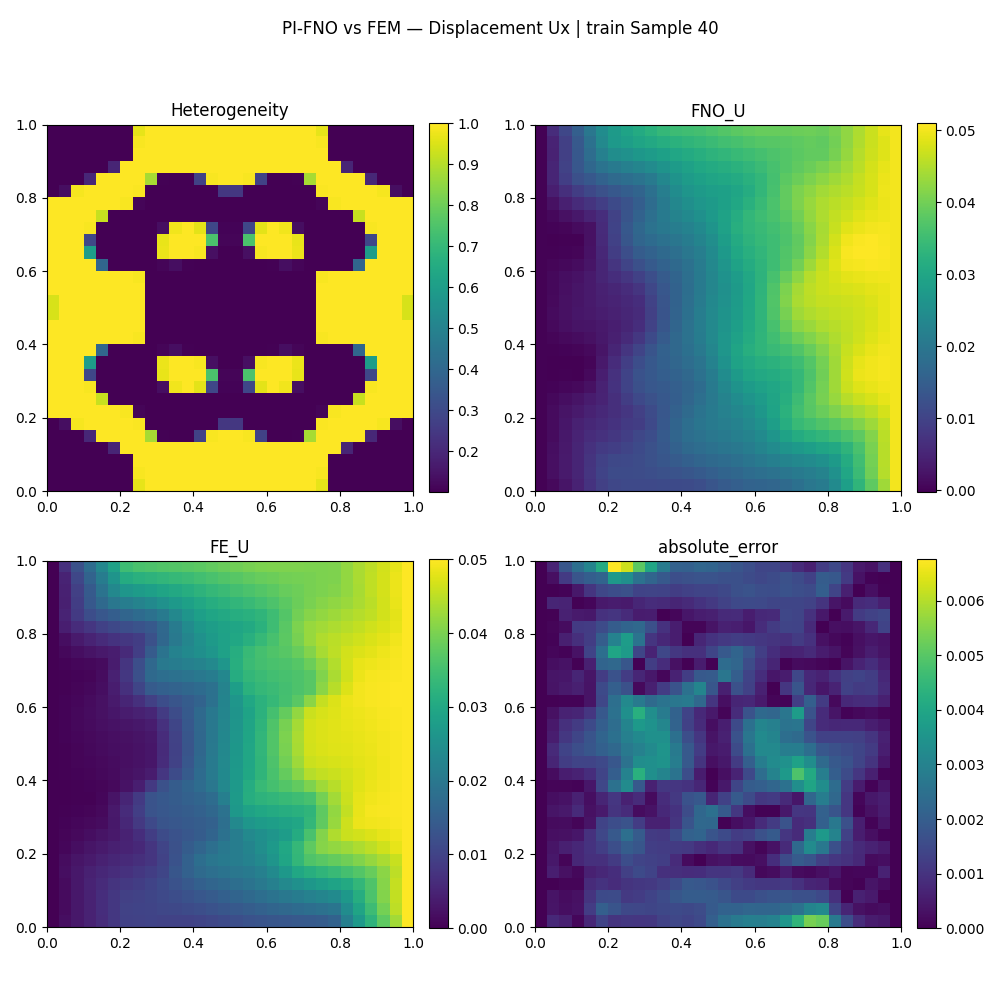

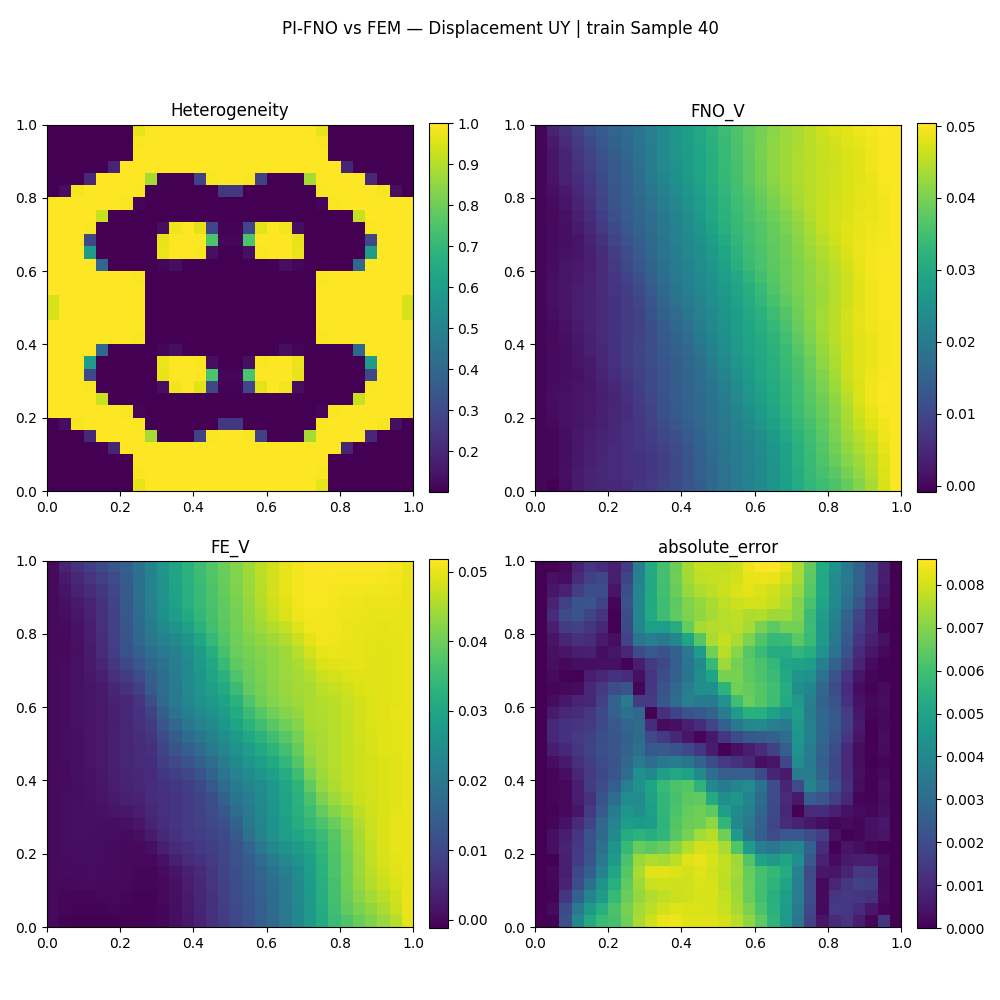

2026-01-28 09:58:51 - Info : mechanical_loss_2d.ApplyDirichletBCOnDofVector - finished in 0.0001 seconds
2026-01-28 09:58:51 - Info : mechanical_loss_2d.ComputeJacobianMatrixAndResidualVector - finished in 0.0022 seconds
2026-01-28 09:58:52 - Info : lin_fe_solver.JaxBicgstabLinearSolver - finished in 0.2595 seconds
2026-01-28 09:58:52 - Info : lin_fe_solver.Solve - finished in 0.2623 seconds


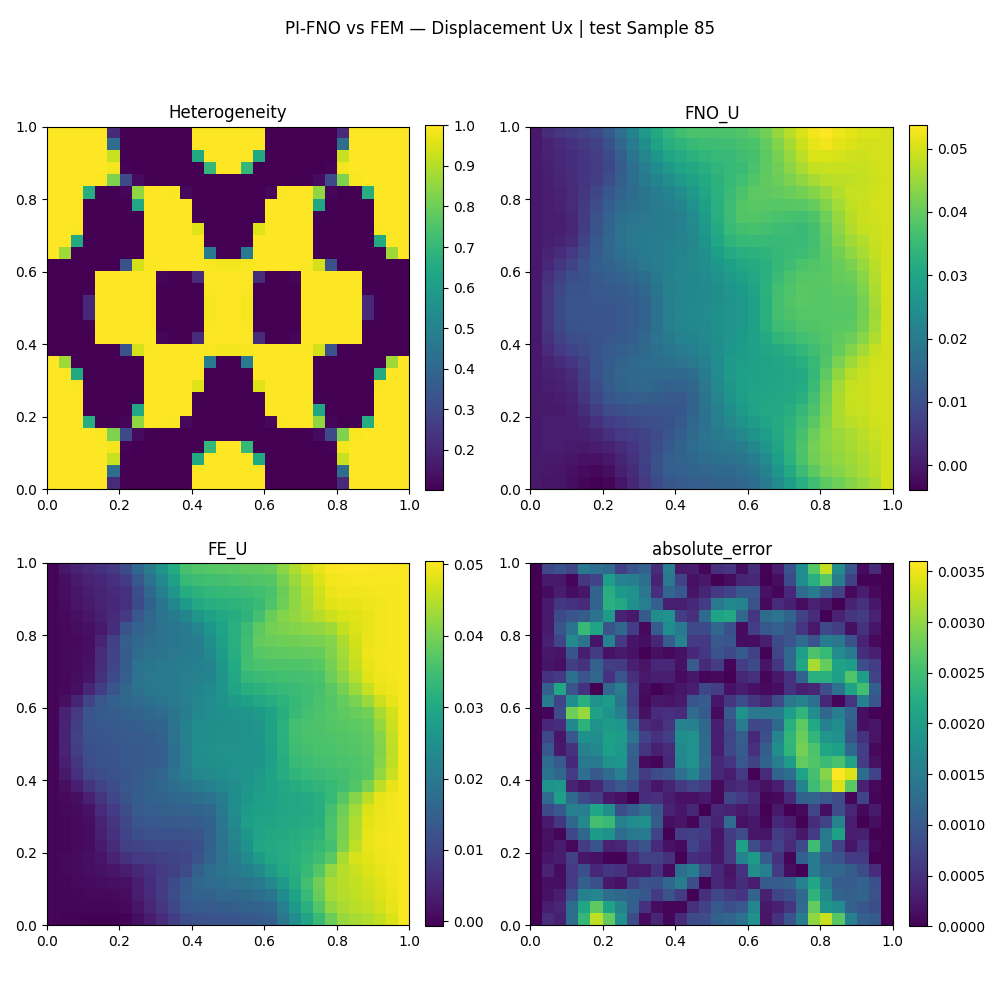

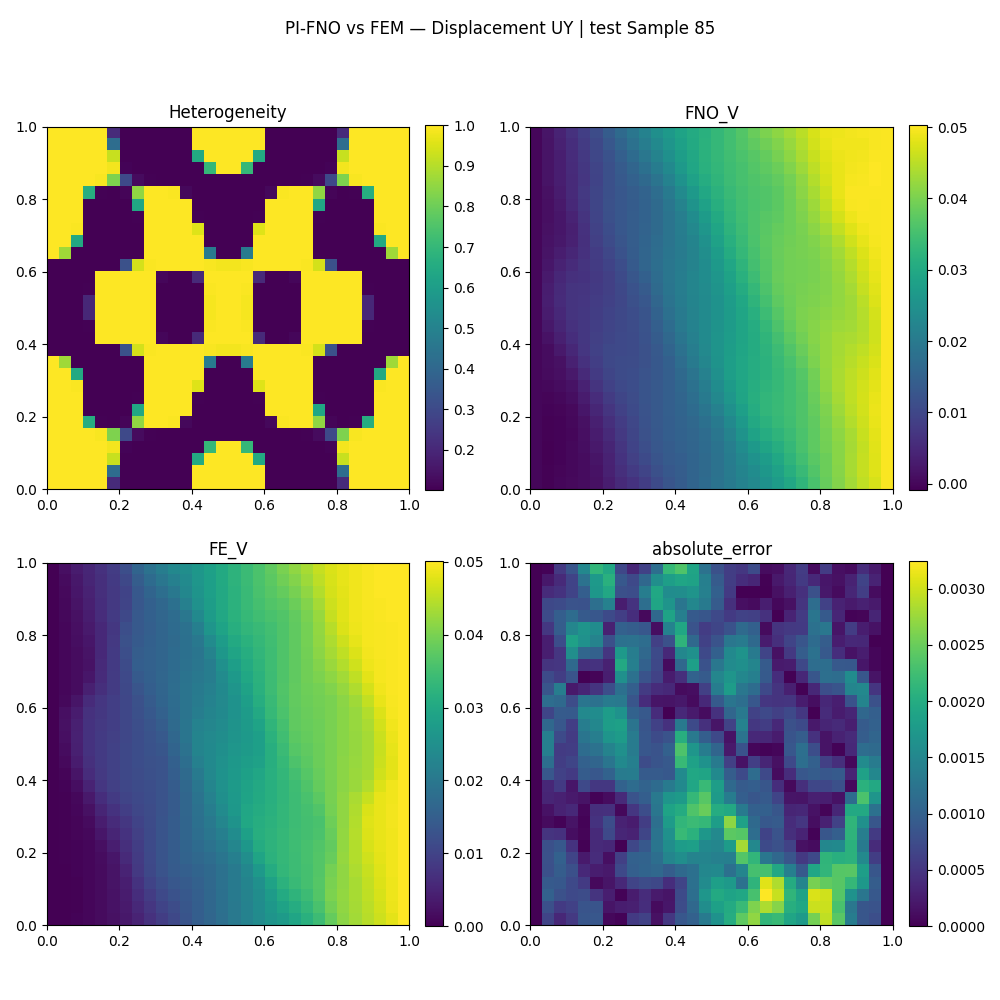

Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to FNO_UV_40.

Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to FE_UV_40.

Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to abs_error_40.

Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to FNO_UV_85.

Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to FE_UV_85.

Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to abs_error_85.

2026-01-28 09:58:53 - Info : square_io.Finalize - finished in 0.0094 seconds


In [ ]:
# ----------------------------------------------------------------------------
# 2.8) Compare PI-FNO vs FE on a subset of train/test samples and plot results
# ----------------------------------------------------------------------------

def plot_set_results(set_ids:np.array,set_name:str):
    """
    For each sample id:
      1) Get FNO predicted displacement field.
      2) Compute FE solution with the same heterogeneity K.
      3) Compute absolute error.
      4) Plot Ux and Uy components separately (plus heterogeneity map).
      5) Store fields on mesh for export (VTK).
    """
    for eval_id in set_ids:
        # ---------------------------------------
        # (A) FNO prediction
        # ---------------------------------------
        # Convert to numpy and flatten into nodal vector ordering:
        # displacement vectors are [Ux0, Uy0, Ux1, Uy1, ...]

        FNO_UV = np.asarray(FNO_UVs[eval_id]).flatten()

        # Store on mesh (shape: n_nodes x 2) for later VTK export
        fe_mesh[f'FNO_UV_{eval_id}'] = FNO_UV.reshape((fe_mesh.GetNumberOfNodes(), 2))

        # ---------------------------------------
        # (B) FE reference solve
        # ---------------------------------------
        # Solve the FE system for this heterogeneity field K
        # RHS is zeros here (no body forces), and Dirichlet BC are handled internally.
        FE_UV = np.asarray(fe_solver.Solve(K_matrix[eval_id],np.zeros(2*fe_mesh.GetNumberOfNodes()))).flatten()

        fe_mesh[f'FE_UV_{eval_id}'] = FE_UV.reshape((fe_mesh.GetNumberOfNodes(), 2))

        # ---------------------------------------
        # (C) Error
        # ---------------------------------------
        absolute_error = abs(FNO_UV- FE_UV)
        fe_mesh[f'abs_error_{eval_id}'] = absolute_error.reshape((fe_mesh.GetNumberOfNodes(), 2))

        # ---------------------------------------
        # (D) Plot Ux and Uy separately
        # ---------------------------------------
        # Ux are even indices: 0,2,4,...
        # Uy are odd indices: 1,3,5,...
        plot_file_name = os.path.join(case_dir,f'{set_name}_{eval_id}_U.png')
        plot_mesh_vec_data(model_settings["L"], [K_matrix[eval_id,:],FNO_UV[::2],FE_UV[::2],absolute_error[::2]],
                           subplot_titles= ['Heterogeneity', 'FNO_U', 'FE_U', "absolute_error"], fig_title = (f"PI-FNO vs FEM — Displacement Ux | " f"{set_name} Sample {eval_id}"),
                           cmap='viridis',block_bool=True, colour_bar=True, colour_bar_name=None,
                           X_axis_name=None, Y_axis_name=None, show=False, file_name=plot_file_name)
        display(Image(filename=plot_file_name))


        plot_file_name = os.path.join(case_dir,f'{set_name}_{eval_id}_V.png')
        plot_mesh_vec_data(model_settings["L"], [K_matrix[eval_id,:],FNO_UV[1::2],FE_UV[1::2],absolute_error[1::2]],
                           subplot_titles= ['Heterogeneity', 'FNO_V', 'FE_V', "absolute_error"], fig_title = (f"PI-FNO vs FEM — Displacement UY | " f"{set_name} Sample {eval_id}"),
                           cmap='viridis',block_bool=True, colour_bar=True, colour_bar_name=None,
                           X_axis_name=None, Y_axis_name=None, show=False, file_name=plot_file_name)
        display(Image(filename=plot_file_name))

# Plot a few training and test samples
plot_set_results([40],"train")
plot_set_results([85],"test")

# Export everything stored on the mesh into VTK for visualization tools (ParaView)
fe_mesh.Finalize(export_dir=case_dir)